Dataset complet       : 2935 échantillons
Dataset Tâche 2 (label=1) : 1751 échantillons
NaN dans width_m      : 0

--- STATISTIQUES WIDTH_M ---
count    1751.000000
mean       36.934272
std        33.576720
min         2.010000
25%        11.125000
50%        25.640000
75%        54.750000
max       154.840000
Name: width_m, dtype: float64


C:\Users\aissa\AppData\Local\Temp\ipykernel_15060\1158380519.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_b, labels=types, patch_artist=True,
C:\Users\aissa\AppData\Local\Temp\ipykernel_15060\1158380519.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax3.boxplot(data_c, labels=covs, patch_artist=True,
C:\Users\aissa\AppData\Local\Temp\ipykernel_15060\1158380519.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax4.boxplot(data_s, labels=shapes, patch_artist=True,


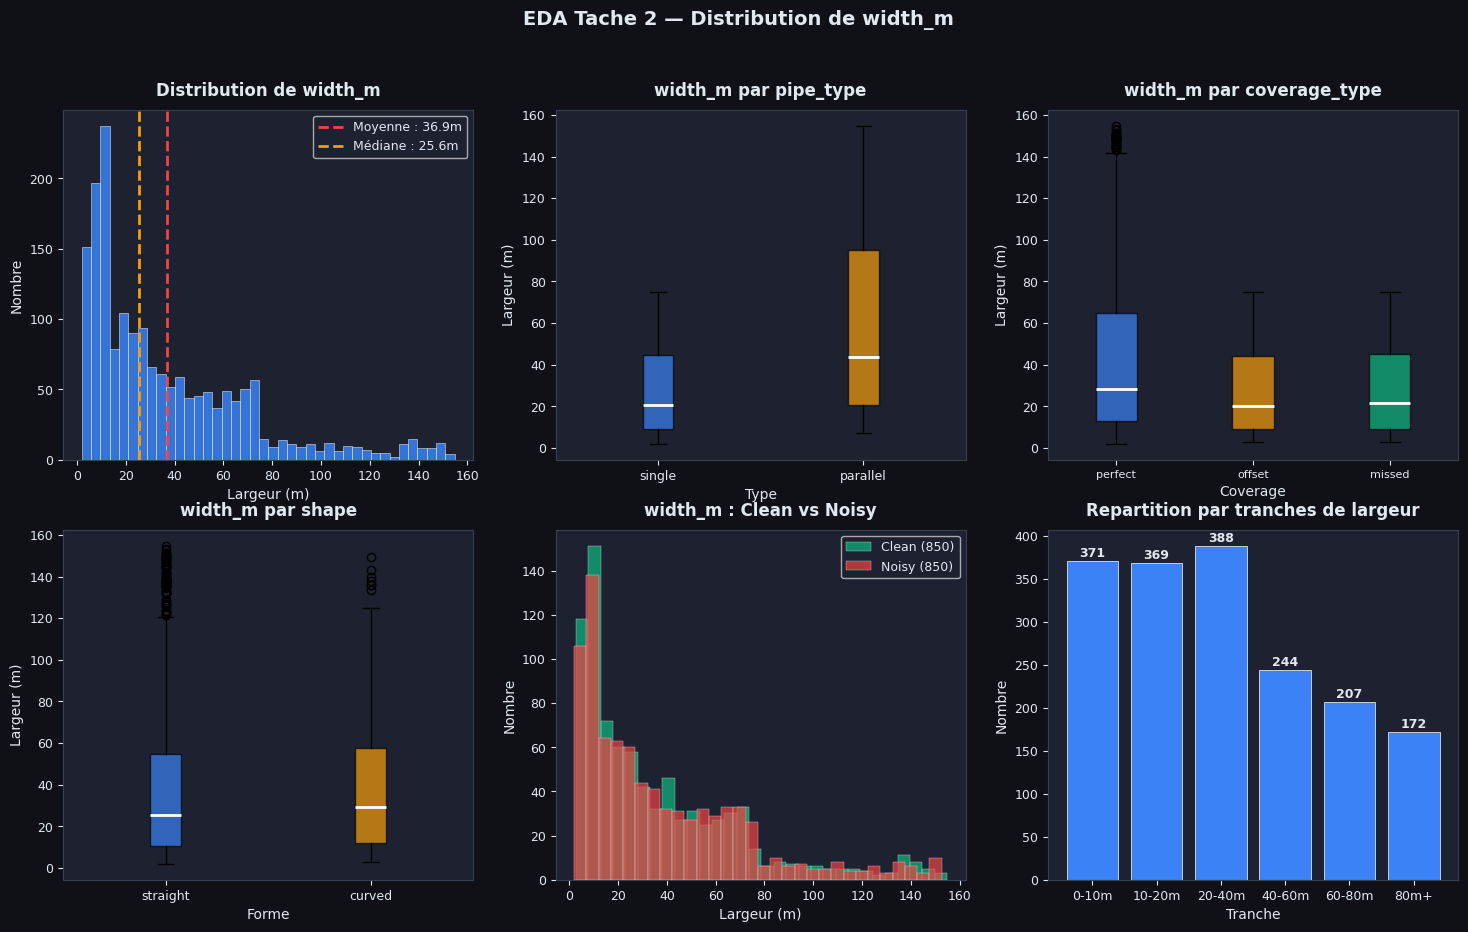


--- CONCLUSION EDA TACHE 2 ---
Min   : 2.01m
Max   : 154.84m
Mean  : 36.93m
Std   : 33.58m
Objectif MAE < 1m — le modele doit etre tres precis.


In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR = "Data_SNDT"
CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# ============================================================
# CHARGEMENT — uniquement label=1 pour la tâche 2
# ============================================================
df      = pd.read_csv(CSV_PATH, sep=';')
df_task2 = df[df['label'] == 1].reset_index(drop=True)

print(f"Dataset complet       : {len(df)} échantillons")
print(f"Dataset Tâche 2 (label=1) : {len(df_task2)} échantillons")
print(f"NaN dans width_m      : {df_task2['width_m'].isna().sum()}")

# ============================================================
# STATISTIQUES DE BASE
# ============================================================
print("\n--- STATISTIQUES WIDTH_M ---")
print(df_task2['width_m'].describe())

# ============================================================
# VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'
C1 = '#3b82f6'
C2 = '#f59e0b'
C3 = '#10b981'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

# --- Graphique 1 : Distribution de width_m ---
ax1 = axes[0, 0]
ax1.hist(df_task2['width_m'], bins=40, color=C1, edgecolor='white', linewidth=0.4, alpha=0.85)
ax1.axvline(df_task2['width_m'].mean(),   color='#ef4444', linestyle='--', linewidth=2, label=f"Moyenne : {df_task2['width_m'].mean():.1f}m")
ax1.axvline(df_task2['width_m'].median(), color=C2,        linestyle='--', linewidth=2, label=f"Médiane : {df_task2['width_m'].median():.1f}m")
ax1.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax1, 'Distribution de width_m')
ax1.set_xlabel('Largeur (m)')
ax1.set_ylabel('Nombre')

# --- Graphique 2 : Boxplot par pipe_type ---
ax2 = axes[0, 1]
types  = df_task2['pipe_type'].dropna().unique()
data_b = [df_task2[df_task2['pipe_type'] == t]['width_m'].dropna().values for t in types]
bp = ax2.boxplot(data_b, labels=types, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
colors_box = [C1, C2, C3]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax2, 'width_m par pipe_type')
ax2.set_xlabel('Type')
ax2.set_ylabel('Largeur (m)')

# --- Graphique 3 : Boxplot par coverage_type ---
ax3 = axes[0, 2]
covs   = df_task2['coverage_type'].dropna().unique()
data_c = [df_task2[df_task2['coverage_type'] == c]['width_m'].dropna().values for c in covs]
bp2 = ax3.boxplot(data_c, labels=covs, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax3, 'width_m par coverage_type')
ax3.set_xlabel('Coverage')
ax3.set_ylabel('Largeur (m)')
ax3.tick_params(axis='x', labelsize=8)

# --- Graphique 4 : width_m par shape ---
ax4 = axes[1, 0]
shapes  = df_task2['shape'].dropna().unique()
data_s  = [df_task2[df_task2['shape'] == s]['width_m'].dropna().values for s in shapes]
bp3 = ax4.boxplot(data_s, labels=shapes, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp3['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax4, 'width_m par shape')
ax4.set_xlabel('Forme')
ax4.set_ylabel('Largeur (m)')

# --- Graphique 5 : width_m Clean vs Noisy ---
ax5 = axes[1, 1]
noisy_vals = df_task2[df_task2['noisy'] == True]['width_m'].dropna()
clean_vals = df_task2[df_task2['noisy'] == False]['width_m'].dropna()
ax5.hist(clean_vals, bins=30, color=C3,        alpha=0.7, edgecolor='white', linewidth=0.3, label=f'Clean ({len(clean_vals)})')
ax5.hist(noisy_vals, bins=30, color='#ef4444', alpha=0.7, edgecolor='white', linewidth=0.3, label=f'Noisy ({len(noisy_vals)})')
ax5.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax5, 'width_m : Clean vs Noisy')
ax5.set_xlabel('Largeur (m)')
ax5.set_ylabel('Nombre')

# --- Graphique 6 : Répartition par tranches ---
ax6 = axes[1, 2]
bins_tranches = [0, 10, 20, 40, 60, 80, 160]
labels_t      = ['0-10m', '10-20m', '20-40m', '40-60m', '60-80m', '80m+']
counts_t      = pd.cut(df_task2['width_m'], bins=bins_tranches, labels=labels_t).value_counts().sort_index()
bars = ax6.bar(counts_t.index, counts_t.values, color=C1, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts_t.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', color=TEXT, fontsize=9, fontweight='bold')
style_ax(ax6, 'Repartition par tranches de largeur')
ax6.set_xlabel('Tranche')
ax6.set_ylabel('Nombre')

fig.suptitle('EDA Tache 2 — Distribution de width_m', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

# ============================================================
# CONCLUSION
# ============================================================
print("\n--- CONCLUSION EDA TACHE 2 ---")
print(f"Min   : {df_task2['width_m'].min():.2f}m")
print(f"Max   : {df_task2['width_m'].max():.2f}m")
print(f"Mean  : {df_task2['width_m'].mean():.2f}m")
print(f"Std   : {df_task2['width_m'].std():.2f}m")
print(f"Objectif MAE < 1m — le modele doit etre tres precis.")

regression

In [10]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import cv2
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR   = "Data_SNDT"
CSV_PATH_2   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
SEED       = 42
MODEL_PATH = "task2_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

# ============================================================
# EXTRACTION DE FEATURES PHYSIQUES
# ============================================================
def extract_features(file_path):
    """
    Extrait des features physiques depuis un fichier NPZ.
    Ces features décrivent directement la forme du signal magnétique
    ce qui est beaucoup plus pertinent pour prédire width_m.
    """
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)

    # Séparer les 4 canaux
    Bx   = data[:, :, 0]
    By   = data[:, :, 1]
    Bz   = data[:, :, 2]
    Norm = data[:, :, 3]

    # Masque des pixels valides (non-NaN à l'origine)
    mask = Norm > 0

    features = {}

    # --- Features globales sur Norm ---
    norm_valid = Norm[mask]
    features['norm_max']    = norm_valid.max()
    features['norm_mean']   = norm_valid.mean()
    features['norm_std']    = norm_valid.std()
    features['norm_median'] = np.median(norm_valid)

    # --- Features globales sur Bz (vertical) ---
    bz_valid = Bz[mask]
    features['bz_max']    = bz_valid.max()
    features['bz_mean']   = bz_valid.mean()
    features['bz_std']    = bz_valid.std()
    features['bz_range']  = bz_valid.max() - bz_valid.min()

    # --- Features globales sur Bx ---
    bx_valid = Bx[mask]
    features['bx_max']   = bx_valid.max()
    features['bx_std']   = bx_valid.std()
    features['bx_range'] = bx_valid.max() - bx_valid.min()

    # --- Features globales sur By ---
    by_valid = By[mask]
    features['by_max']   = by_valid.max()
    features['by_std']   = by_valid.std()
    features['by_range'] = by_valid.max() - by_valid.min()

    # --- Dimensions spatiales de la carte ---
    # Nombre de pixels valides et dimensions
    features['n_valid_pixels'] = mask.sum()
    features['height']         = data.shape[0]
    features['width_pixels']   = data.shape[1]
    features['aspect_ratio']   = data.shape[0] / (data.shape[1] + 1e-6)

    # --- Profil moyen sur l'axe court (largeur physique) ---
    # On prend le profil de Norm sur chaque colonne
    col_means = Norm.mean(axis=0)   # moyenne sur les lignes
    row_means = Norm.mean(axis=1)   # moyenne sur les colonnes

    # Largeur du profil au-dessus du seuil (50% du max)
    threshold = col_means.max() * 0.5
    above     = col_means > threshold
    features['profile_width_cols'] = above.sum()

    threshold2 = row_means.max() * 0.5
    above2     = row_means > threshold2
    features['profile_width_rows'] = above2.sum()

    # --- Gradient spatial (mesure de la variation du champ) ---
    grad_x = np.gradient(Norm, axis=1)
    grad_y = np.gradient(Norm, axis=0)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    features['grad_mean'] = grad_magnitude[mask].mean()
    features['grad_max']  = grad_magnitude[mask].max()

    # --- Ratio pixels valides / total ---
    features['coverage_ratio'] = mask.mean()

    # --- Dimensions physiques en mètres (1 pixel = 0.2m) ---
    features['height_m']       = data.shape[0] * 0.2
    features['width_pixels_m'] = data.shape[1] * 0.2

    return list(features.values())

Device : cpu


In [11]:
# ============================================================
# CHARGEMENT ET EXTRACTION DES FEATURES
# ============================================================
df       = pd.read_csv(CSV_PATH_2, sep=';')
df_task2 = df[df['label'] == 1].reset_index(drop=True)
print(f"Echantillons tâche 2 : {len(df_task2)}")

print("Extraction des features physiques...")
X_list = []
y_list = []

for i, row in df_task2.iterrows():
    file_path = os.path.join(DATA_DIR, row['field_file'])
    feats = extract_features(file_path)
    X_list.append(feats)
    y_list.append(row['width_m'])
    if len(X_list) % 200 == 0:
        print(f"  {len(X_list)}/{len(df_task2)} fichiers traités...")

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
print(f"Shape X : {X.shape}  => ({len(X)} échantillons, {X.shape[1]} features)")
print(f"Shape y : {y.shape}")

Echantillons tâche 2 : 1751
Extraction des features physiques...
  200/1751 fichiers traités...
  400/1751 fichiers traités...
  600/1751 fichiers traités...
  800/1751 fichiers traités...
  1000/1751 fichiers traités...
  1200/1751 fichiers traités...
  1400/1751 fichiers traités...
  1600/1751 fichiers traités...
Shape X : (1751, 25)  => (1751 échantillons, 25 features)
Shape y : (1751,)


In [12]:
# ============================================================
# SPLIT + NORMALISATION DES FEATURES
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

# StandardScaler sur les features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Conversion en tenseurs
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoaders
train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
val_ds   = torch.utils.data.TensorDataset(X_val_t,   y_val_t)
test_ds  = torch.utils.data.TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# ============================================================
# MODÈLE MLP (réseau de neurones sur les features)
# ============================================================
n_features = X_train.shape[1]

class WidthMLP(nn.Module):
    """
    MLP (Multi-Layer Perceptron) pour régression sur features physiques.
    Plus adapté qu'un CNN pour des features numériques extraites.
    """
    def __init__(self, n_features):
        super(WidthMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model     = WidthMLP(n_features).to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
print(f"Paramètres MLP : {sum(p.numel() for p in model.parameters()):,}")

Train : 1225 | Val : 263 | Test : 263
Paramètres MLP : 13,697


In [13]:
# ============================================================
# ENTRAINEMENT
# ============================================================
EPOCHS  = 300
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_val_loss = float('inf')

print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train MAE':<12} {'Val MAE (m)'}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_preds, train_labels = [], []
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
        train_preds.extend(out.detach().cpu().numpy())
        train_labels.extend(yb.cpu().numpy())

    train_loss /= len(train_ds)
    train_mae   = mean_absolute_error(train_labels, train_preds)

    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out  = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_preds.extend(out.cpu().numpy())
            val_labels.extend(yb.cpu().numpy())

    val_loss /= len(val_ds)
    val_mae   = mean_absolute_error(val_labels, val_preds)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_mae:<12.2f} {val_mae:.2f}m{saved}")


Epoch    Train Loss   Val Loss     Train MAE    Val MAE (m)
------------------------------------------------------------
1        33.9607      29.6285      34.46        30.12m <= sauvegardé
5        12.5739      11.8361      13.06        12.32m <= sauvegardé
10       9.9161       9.6806       10.40        10.17m <= sauvegardé
15       9.1360       8.5514       9.61         9.03m <= sauvegardé
20       8.2760       7.6454       8.75         8.11m <= sauvegardé
25       8.1450       7.1067       8.62         7.58m <= sauvegardé
30       7.8437       6.8097       8.31         7.27m <= sauvegardé
35       7.5966       6.7432       8.07         7.21m
40       7.5362       6.5761       8.01         7.05m
45       7.4742       6.3047       7.95         6.76m
50       7.3682       6.0657       7.84         6.53m <= sauvegardé
55       7.2021       6.1308       7.67         6.59m
60       7.2664       6.3727       7.74         6.83m
65       7.1048       5.9244       7.57         6.39m
70     

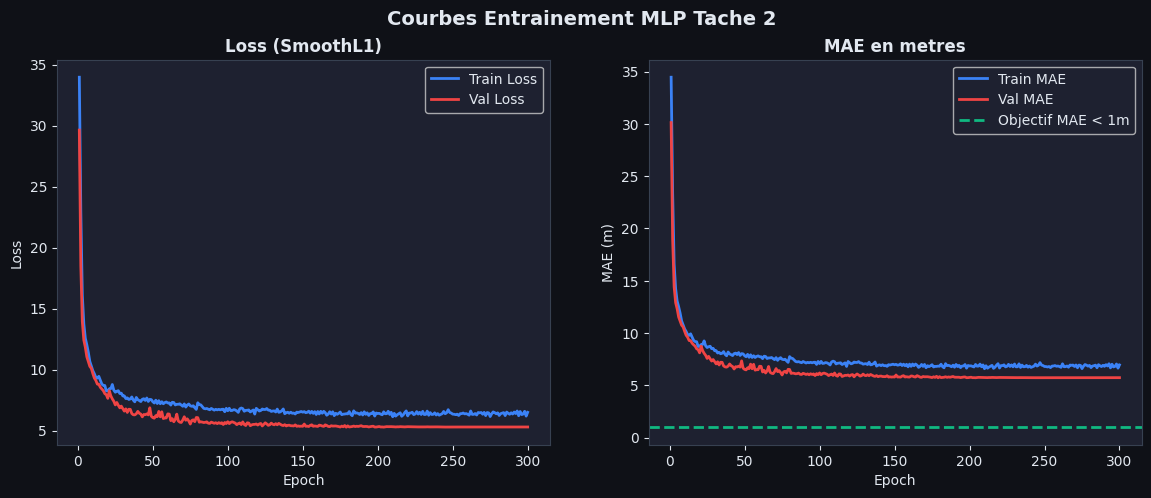

In [14]:
# ============================================================
# VISUALISATION COURBES
# ============================================================
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss (SmoothL1)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_mae'], color='#3b82f6', label='Train MAE', linewidth=2)
axes[1].plot(epochs_range, history['val_mae'],   color='#ef4444', label='Val MAE',   linewidth=2)
axes[1].axhline(1.0, color='#10b981', linestyle='--', linewidth=2, label='Objectif MAE < 1m')
style_ax(axes[1], 'MAE en metres')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (m)')
fig.suptitle('Courbes Entrainement MLP Tache 2', color=TEXT, fontsize=14, fontweight='bold')
plt.show()


--- EVALUATION FINALE SUR LE TEST SET ---
MAE finale : 5.0096m  (objectif < 1m)


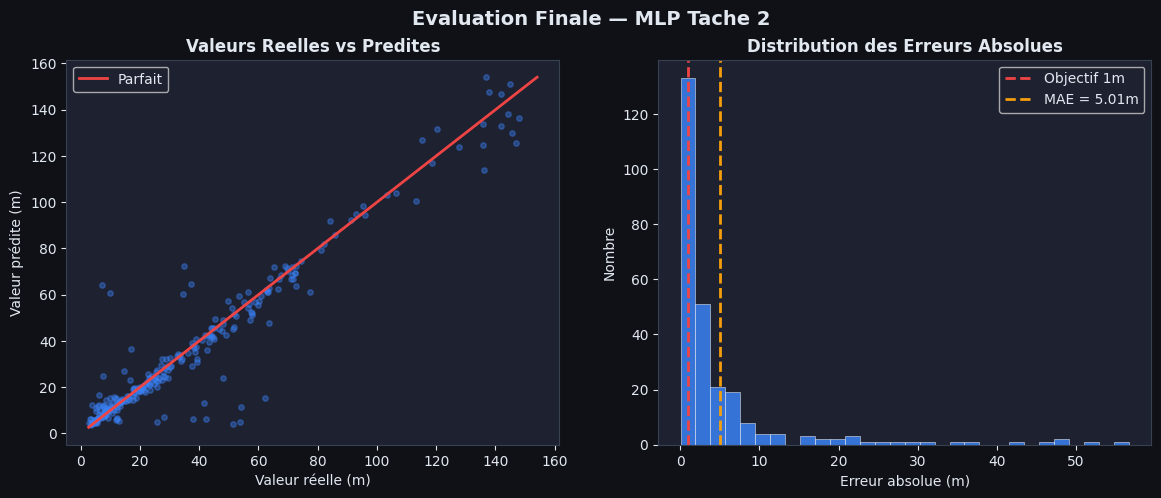

In [15]:
# ============================================================
# EVALUATION FINALE
# ============================================================
print("\n--- EVALUATION FINALE SUR LE TEST SET ---")
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(DEVICE))
        all_preds.extend(out.cpu().numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
mae        = mean_absolute_error(all_labels, all_preds)
print(f"MAE finale : {mae:.4f}m  (objectif < 1m)")

# Graphiques évaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

axes[0].scatter(all_labels, all_preds, alpha=0.4, color='#3b82f6', s=15)
min_v, max_v = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color='#ef4444', linewidth=2, label='Parfait')
style_ax(axes[0], 'Valeurs Reelles vs Predites')
axes[0].set_xlabel('Valeur réelle (m)')
axes[0].set_ylabel('Valeur prédite (m)')

erreurs = np.abs(all_preds - all_labels)
axes[1].hist(erreurs, bins=30, color='#3b82f6', edgecolor='white', linewidth=0.4, alpha=0.85)
axes[1].axvline(1.0,           color='#ef4444', linestyle='--', linewidth=2, label='Objectif 1m')
axes[1].axvline(erreurs.mean(), color='#f59e0b', linestyle='--', linewidth=2, label=f'MAE = {erreurs.mean():.2f}m')
style_ax(axes[1], 'Distribution des Erreurs Absolues')
axes[1].set_xlabel('Erreur absolue (m)')
axes[1].set_ylabel('Nombre')
fig.suptitle('Evaluation Finale — MLP Tache 2', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

In [16]:
import joblib
joblib.dump(scaler, "task2_scaler.pkl")
print("Scaler sauvegardé !")

Scaler sauvegardé !
